In [7]:
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv(r"D:/ML/DataSet/college_student_placement_dataset.csv")

In [9]:
df.head()       #this is used to take a overview of the dataset

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [10]:
df.shape

(10000, 10)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  str    
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  str    
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  str    
dtypes: float64(2), int64(5), str(3)
memory usage: 781.4 KB


 Steps

 0. Preprocess + EDA + Feature SelectionlI
 1. Extract input and output cols
 2. Scale the values
 3. Train test split
 4. Train the model
 5. Evaluate the model/model selection
 6. Deploy the model

In [12]:
df = df.iloc[:,[1,3,5,8,9]]     #this can be ussed to short or remove the unnecessary rows and columns . here we are keeping selected columns but all rows

In [13]:
df.head()

,IQ,CGPA,Internship_Experience,Projects_Completed,Placement
0,107,6.28,No,4,No
1,97,5.37,No,0,No
2,109,5.83,No,1,No
3,122,5.75,Yes,1,No
4,96,7.69,No,2,No


In [14]:
import matplotlib.pyplot as plt

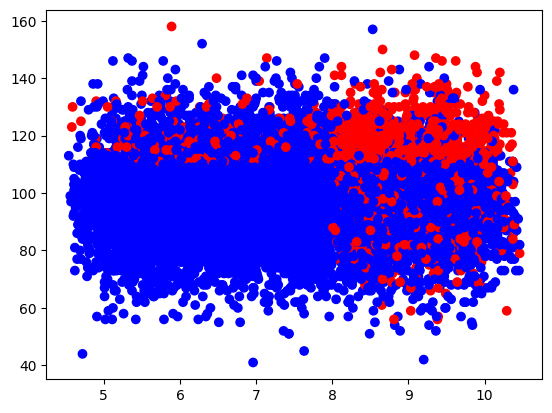

In [15]:
color_map = df['Placement'].map({'No': 'blue', 'Yes': 'red'})
plt.scatter(df['CGPA'], df['IQ'], c=color_map)


here, in the 1st line : color_map = df['Placement'].map({'No': 'blue', 'Yes': 'red'}) :: we are taking Placement column from df and then mapping it such that if the element is NO the point on graph will be blue and if yes it will be red

in 2nd line : plt.scatter(df['CGPA'], df['IQ'], c=color_map) :: we are plotting a graph(scattered i.e we are just plotting the points) , where at x axis we have cgpa and on y we have iq. we also tell to follow colour map made in first line

<Axes: xlabel='Placement'>

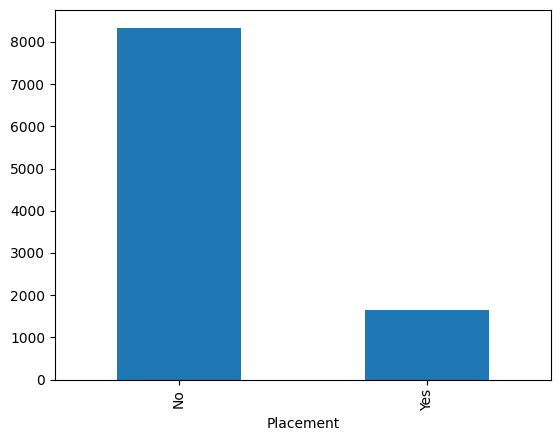

In [16]:
df['Placement'].value_counts().plot(kind='bar')

We are going to use : Logistic regression,it generally cuts the input using a line separating the cases

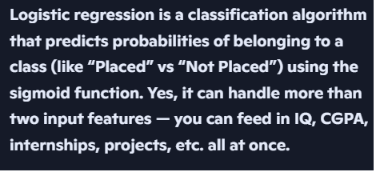

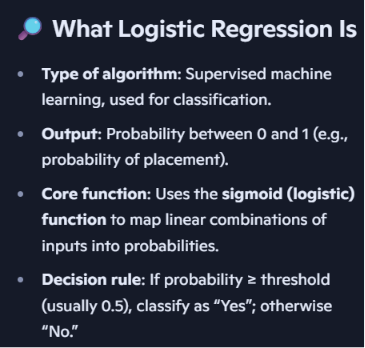

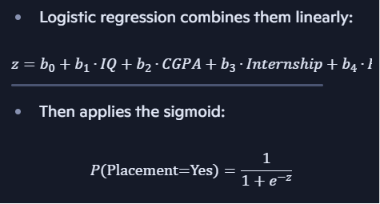

In [17]:
df['Internship_Experience'] = df['Internship_Experience'].replace({'Yes': 1, 'No': 0})
df['Placement'] = df['Placement'].replace({'Yes': 1, 'No': 0})
#we have used replace to replace 'yes' and 'no' with 0 and 1

In [18]:
df['Internship_Experience'] = df['Internship_Experience'].astype(int)
df['Placement'] = df['Placement'].astype(int)

In [19]:
df.head()

,IQ,CGPA,Internship_Experience,Projects_Completed,Placement
0,107,6.28,0,4,0
1,97,5.37,0,0,0
2,109,5.83,0,1,0
3,122,5.75,1,1,0
4,96,7.69,0,2,0


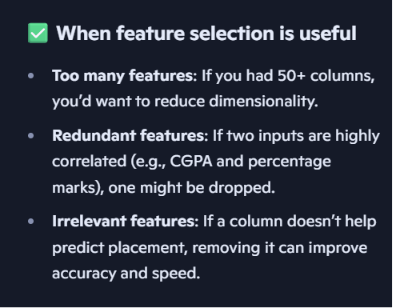

In [20]:
X = df.iloc[:,0:4]   #we are going to store independent variables in this.
y = df.iloc[:,-1]       #we are going to store dependent variables in this and -1 means last column.

In [21]:
X


,IQ,CGPA,Internship_Experience,Projects_Completed
0,107,6.28,0,4
1,97,5.37,0,0
2,109,5.83,0,1
3,122,5.75,1,1
4,96,7.69,0,2
...,...,...,...,...
9995,119,8.29,0,0
9996,70,9.34,0,2
9997,89,6.25,1,5
9998,107,8.92,0,1


In [22]:
y

0       0
1       0
2       0
3       0
4       0
       ..
9995    1
9996    0
9997    0
9998    0
9999    0
Name: Placement, Length: 10000, dtype: int64

In [23]:
y.shape

(10000,)

In [25]:
from sklearn.model_selection import train_test_split        
#this library is used to split data that we will use later for testing

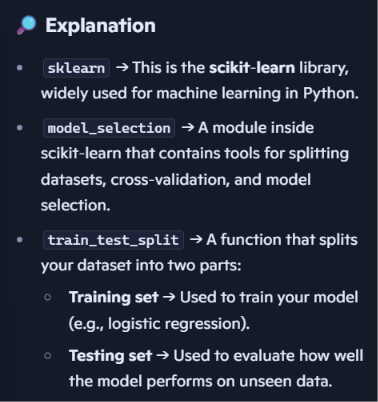

In [26]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


     
#this function take independent , dependent variable and the size of / no. of data to be stored for testing in later case

In [27]:
x_test

,IQ,CGPA,Internship_Experience,Projects_Completed
6252,139,7.24,0,4
4684,84,8.49,1,5
1731,94,5.66,0,4
4742,100,6.29,1,3
4521,116,6.39,0,5
...,...,...,...,...
6412,72,7.40,0,3
8285,114,7.95,1,2
7853,108,8.81,1,1
1095,98,9.63,0,0


In [28]:
y_test

6252    0
4684    0
1731    0
4742    0
4521    1
       ..
6412    0
8285    0
7853    0
1095    0
6929    0
Name: Placement, Length: 2000, dtype: int64

In [29]:
x_train

,IQ,CGPA,Internship_Experience,Projects_Completed
9254,103,6.96,0,1
1561,88,5.02,1,1
1670,96,6.99,0,4
6087,76,6.22,1,1
6669,110,8.06,1,2
...,...,...,...,...
5734,91,9.72,0,1
5191,99,7.36,0,0
5390,89,6.66,1,5
860,103,7.57,0,2


In [30]:
y_train

9254    0
1561    0
1670    0
6087    0
6669    0
       ..
5734    0
5191    0
5390    0
860     0
7270    0
Name: Placement, Length: 8000, dtype: int64

#now we are going to scale the input in -1 to 1 range

In [31]:
from sklearn.preprocessing import StandardScaler        #this is to scale

In [32]:
scaler = StandardScaler()

In [33]:
x_train = scaler.fit_transform(x_train)        #this ".fit_transform" will 1st understand what is x/data an then do transformation
#learn the syntax       #here we understand the pattern of the data being followed.ML model training!

In [34]:
x_train

array([[ 0.22949886, -0.38674212, -0.80970929, -0.88477013],
       [-0.76655391, -1.70492153,  1.23501114, -0.88477013],
       [-0.23532577, -0.3663579 , -0.80970929,  0.86091247],
       ...,
       [-0.70015039, -0.5905843 ,  1.23501114,  1.44280667],
       [ 0.22949886,  0.02773697, -0.80970929, -0.30287593],
       [-1.69620317, -0.7128896 ,  1.23501114, -1.46666434]],
      shape=(8000, 4))

In [35]:
x_test = scaler.transform(x_test)       #now since we have learned the pattern so we will directly transform

In [36]:
x_test

array([[ 2.62002551, -0.19648942, -0.80970929,  0.86091247],
       [-1.03216799,  0.65285299,  1.23501114,  1.44280667],
       [-0.3681328 , -1.27005822, -0.80970929,  0.86091247],
       ...,
       [ 0.56151645,  0.87028464,  1.23501114, -0.88477013],
       [-0.10251873,  1.42745326, -0.80970929, -1.46666434],
       [-1.0985715 , -0.50225269,  1.23501114, -1.46666434]],
      shape=(2000, 4))

--------------------------------------------------------------------------------------------------

#Now we are going to train our Model!!!!

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
clf = LogisticRegression()      #clf = classifier, we are making object of LogisticRegression class

In [39]:
clf.fit(x_train,y_train)       #we use this clf.fit() to train the model
#we just have to provide the training data

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

here, our training is completed

---------------------------------------------------------------------------------------------

Now time for evaluating the model!

In [40]:
y_predict = clf.predict(x_test)     #here we are predecting the output

In [41]:
y_predict

array([1, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [42]:
y_test

6252    0
4684    0
1731    0
4742    0
4521    1
       ..
6412    0
8285    0
7853    0
1095    0
6929    0
Name: Placement, Length: 2000, dtype: int64

In [43]:
from sklearn.metrics import accuracy_score      #this help us to find accuracy score

In [44]:
accuracy_score(y_test,y_predict)        #we have to give 1st input as correct values and 2nd as predicted values

0.8565

now we are going to find the decision boundary

learn or just remember this code exists

ValueError: Filler values must be provided when X has more than 2 training features.

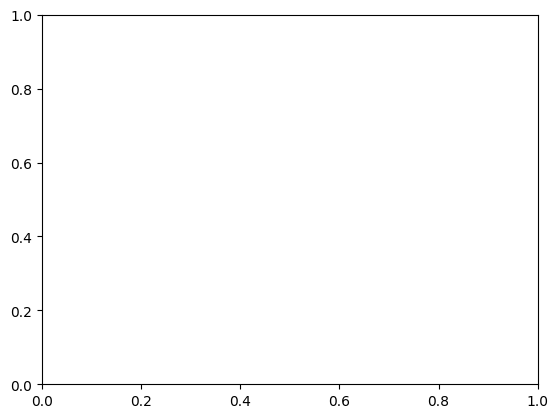

In [46]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x_train,y_train.values, clf=clf, legend=2)

we are not getting the answer as the plot_decision_regions can work with 2 inputs only but we have 4

---------------------------------------------------------------------------------------------

#Deploying it as website

In [ ]:
import pickle   #inpython every thing is a object. Pickle convert everything to file

In [ ]:
pickle.dump(clf,open('Day13_model.pkl','wb'))